Imports

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

df = pd.read_csv("../data/models/metrics.csv")
df

,model,val_f1,val_precision,val_recall,val_accuracy,test_f1,test_precision,test_recall,test_accuracy
0,logistic_regression,0.209246,0.343783,0.335889,0.335889,0.247113,0.400055,0.261325,0.261325
1,random_forest,0.164196,0.109232,0.330502,0.330502,0.398041,0.407778,0.414350,0.414350
2,xgboost,0.164357,0.274464,0.330469,0.330469,0.389368,0.385955,0.403725,0.403725
3,LightGBM,0.164448,0.246900,0.330403,0.330403,0.402424,0.409972,0.420300,0.420300
4,catboost,0.215795,0.260124,0.301418,0.301418,0.373146,0.540778,0.441100,0.441100


Sort models by test F1 for consistent plotting

In [9]:
df_sorted = df.sort_values(by="test_f1", ascending=False)
df_sorted

,model,val_f1,val_precision,val_recall,val_accuracy,test_f1,test_precision,test_recall,test_accuracy
3,LightGBM,0.164448,0.246900,0.330403,0.330403,0.402424,0.409972,0.420300,0.420300
1,random_forest,0.164196,0.109232,0.330502,0.330502,0.398041,0.407778,0.414350,0.414350
2,xgboost,0.164357,0.274464,0.330469,0.330469,0.389368,0.385955,0.403725,0.403725
4,catboost,0.215795,0.260124,0.301418,0.301418,0.373146,0.540778,0.441100,0.441100
0,logistic_regression,0.209246,0.343783,0.335889,0.335889,0.247113,0.400055,0.261325,0.261325


Bar Charts for Test Metrics

C:\Users\johnm\AppData\Local\Temp\ipykernel_20296\6648887.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_sorted["model"], rotation=45, ha="right")
C:\Users\johnm\AppData\Local\Temp\ipykernel_20296\6648887.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_sorted["model"], rotation=45, ha="right")
C:\Users\johnm\AppData\Local\Temp\ipykernel_20296\6648887.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_sorted["model"], rotation=45, ha="right")
C:\Users\johnm\AppData\Local\Temp\ipykernel_20296\6648887.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_sorted

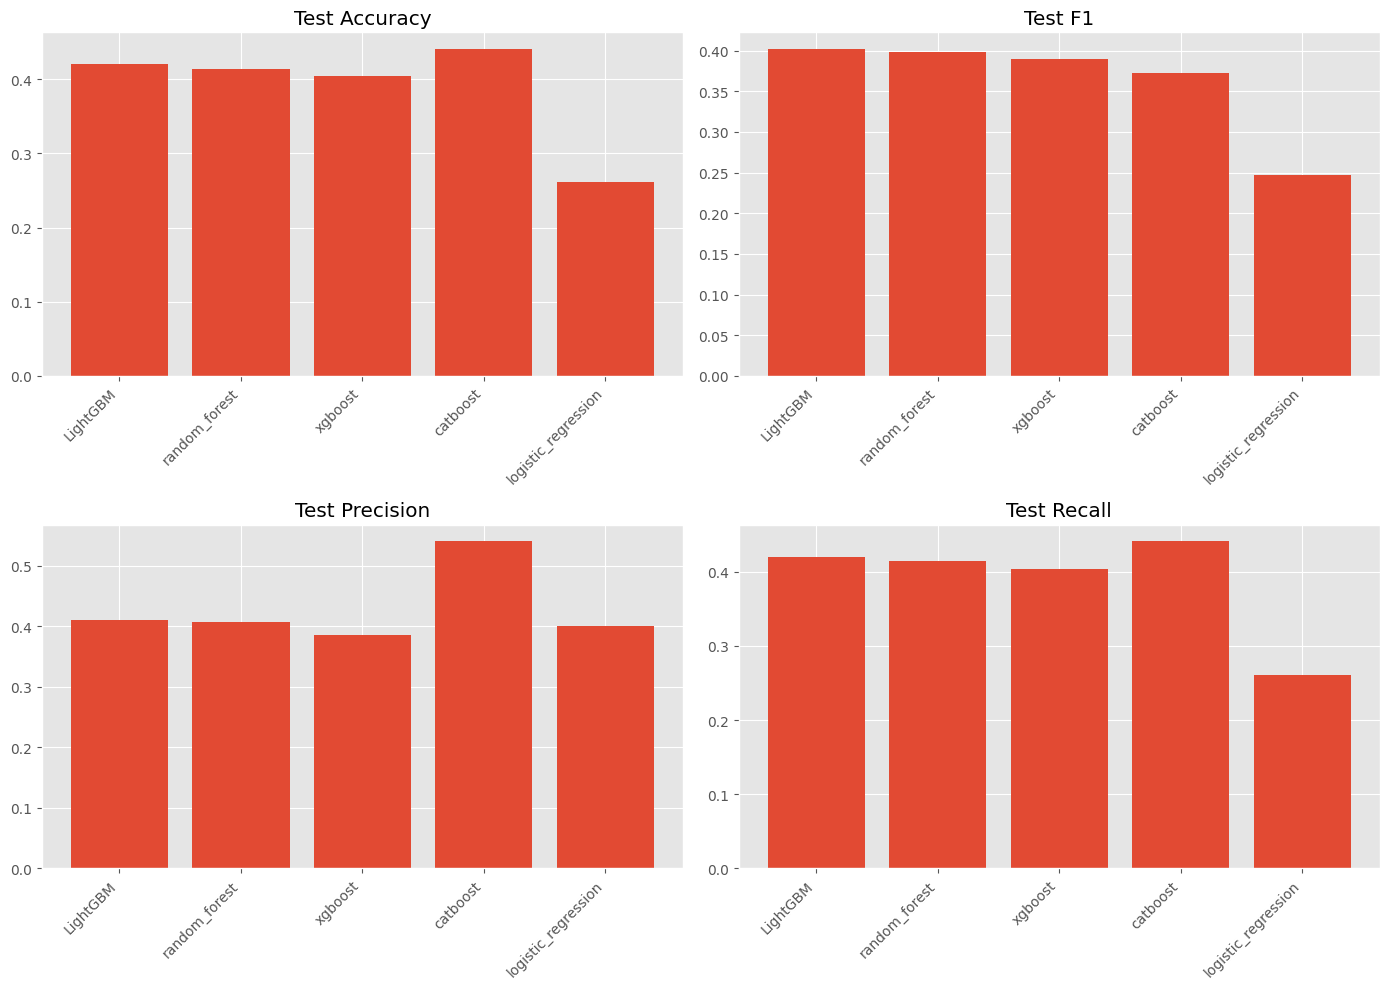

In [12]:
metrics = ["test_accuracy", "test_f1", "test_precision", "test_recall"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, metric in enumerate(metrics):
    ax = axes[i]
    ax.bar(df_sorted["model"], df_sorted[metric])
    ax.set_title(f"{metric.replace('_', ' ').title()}")
    ax.set_xticklabels(df_sorted["model"], rotation=45, ha="right")

plt.tight_layout()
plt.savefig("../figures/model_performance_metrics.png")
plt.show()

Validation vs Test Comparision

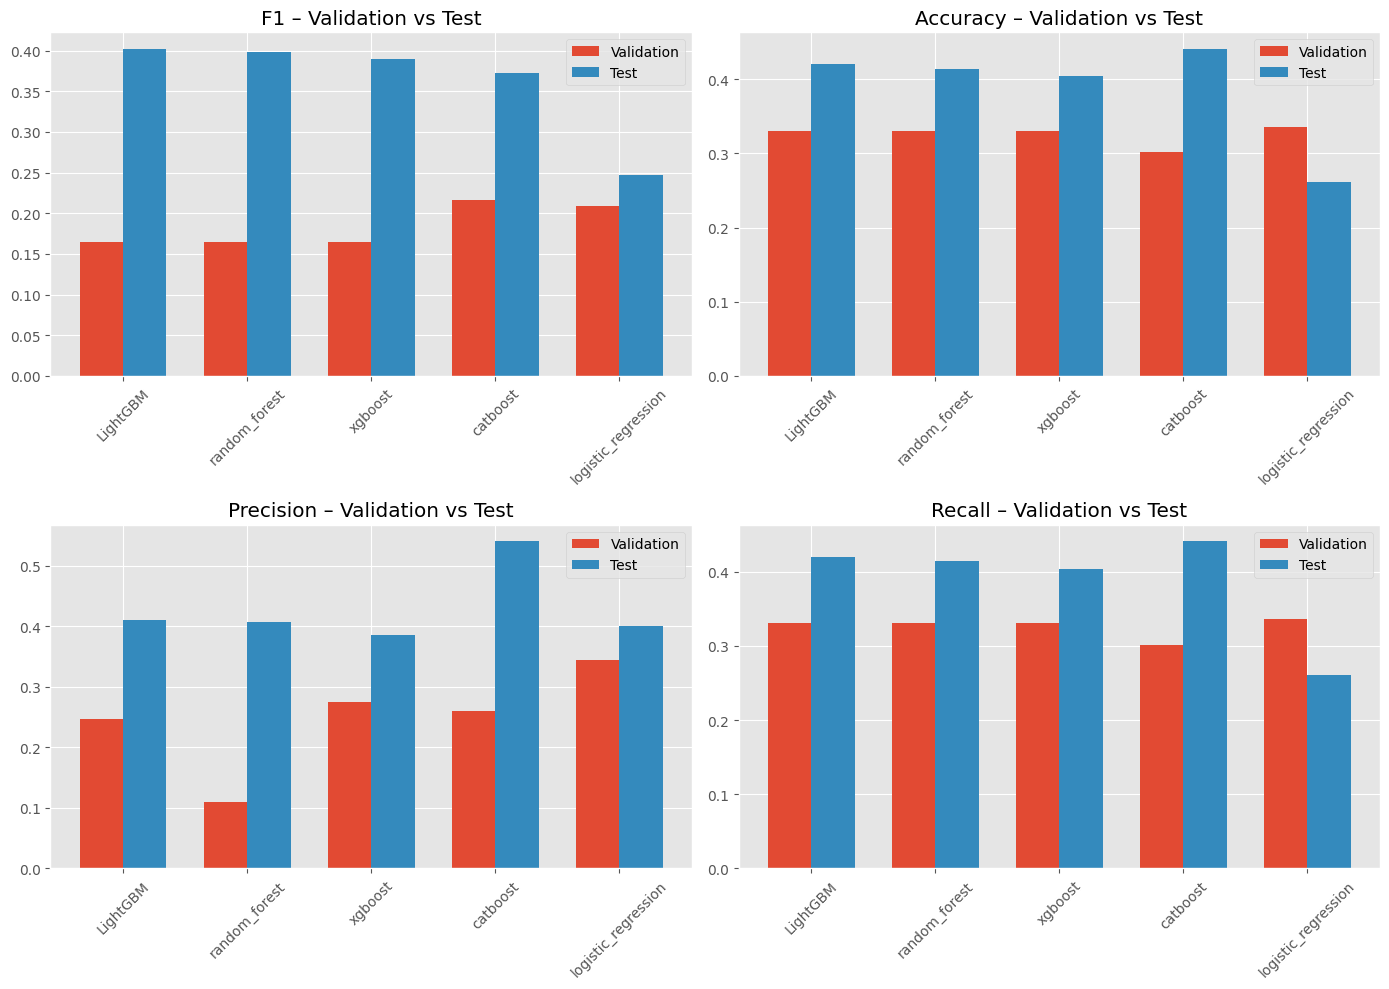

In [13]:
pairs = [
    ("val_f1", "test_f1"),
    ("val_accuracy", "test_accuracy"),
    ("val_precision", "test_precision"),
    ("val_recall", "test_recall")
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

x = np.arange(len(df_sorted["model"]))
width = 0.35

for i, (v, t) in enumerate(pairs):
    ax = axes[i]
    ax.bar(x - width/2, df_sorted[v], width, label="Validation")
    ax.bar(x + width/2, df_sorted[t], width, label="Test")
    ax.set_title(f"{v.replace('val_', '').title()} – Validation vs Test")
    ax.set_xticks(x)
    ax.set_xticklabels(df_sorted["model"], rotation=45)
    ax.legend()

plt.tight_layout()
plt.savefig("../figures/val_vs_test_metrics.png")
plt.show()

Radar Plots

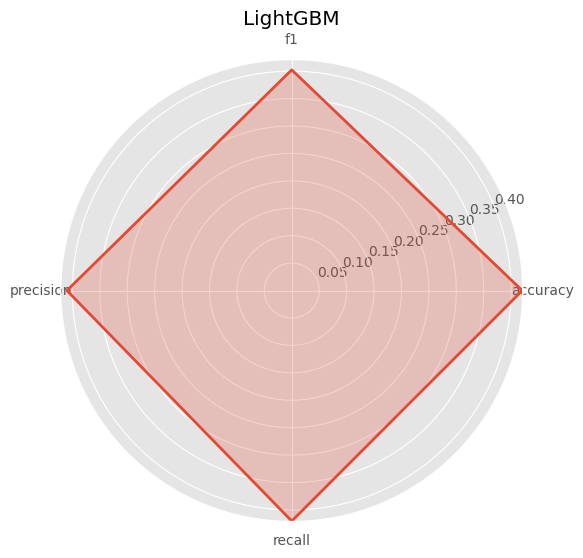

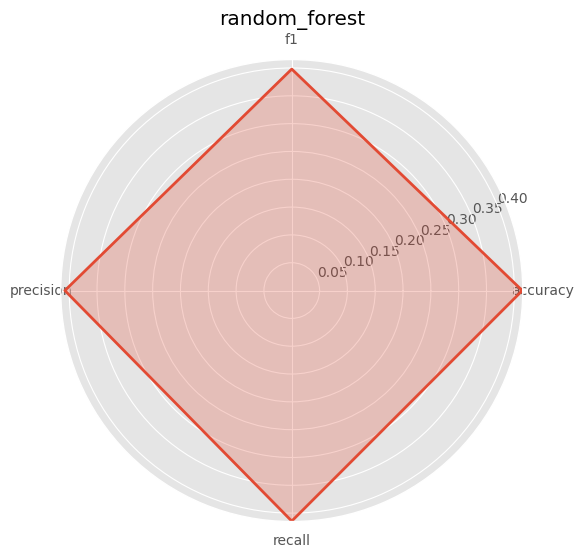

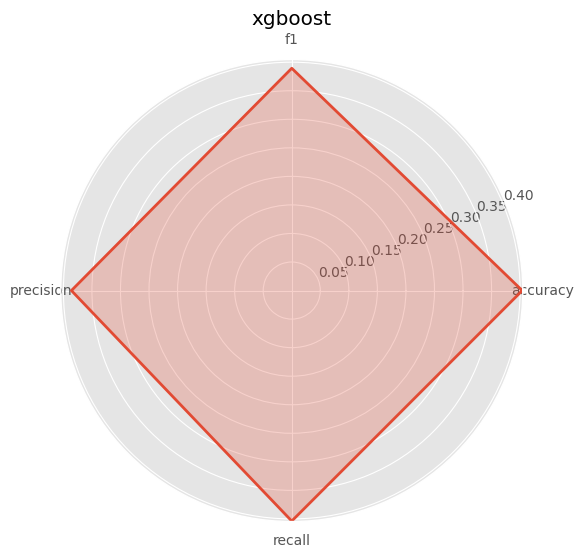

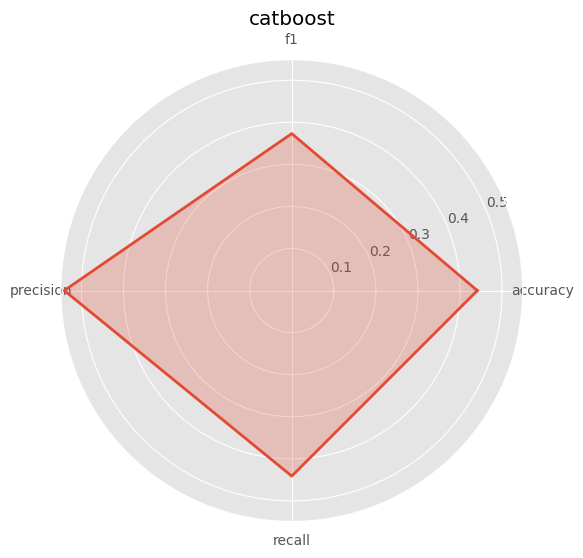

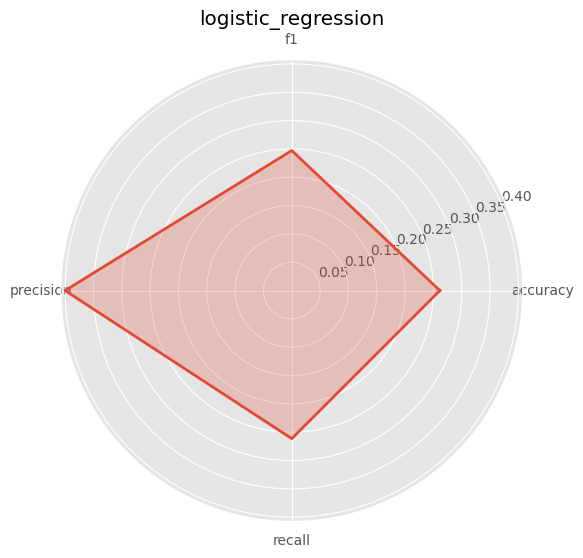

In [14]:
metrics = ["test_accuracy", "test_f1", "test_precision", "test_recall"]

def radar_plot(row):
    values = row[metrics].values
    labels = metrics
    
    angles = np.linspace(0, 2 * np.pi, len(values), endpoint=False)
    values = np.concatenate([values, values[:1]])
    angles = np.concatenate([angles, angles[:1]])

    fig = plt.figure(figsize=(6, 6))
    ax = plt.subplot(111, polar=True)
    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([m.replace('test_', '') for m in metrics])
    ax.set_title(row["model"])
    plt.savefig(f"../figures/radar_{row['model']}.png")
    plt.show()

for _, row in df_sorted.iterrows():
    radar_plot(row)

Ranking plot based on Test F1

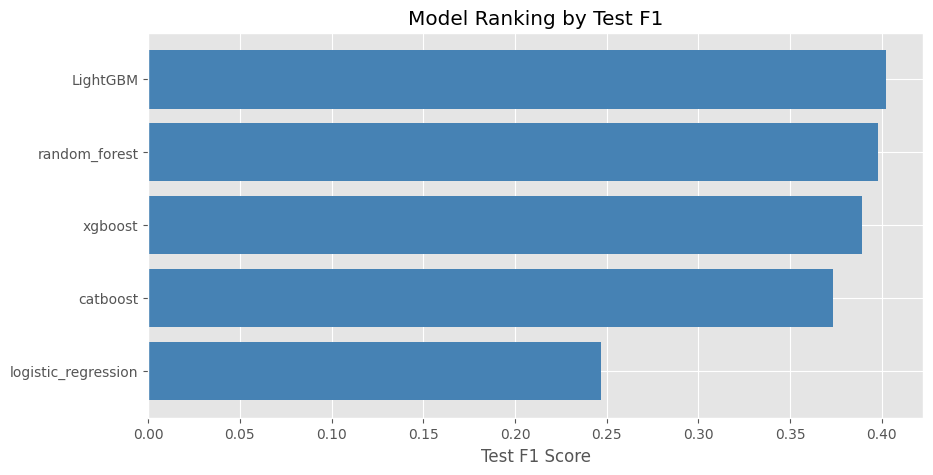

In [15]:
plt.figure(figsize=(10, 5))
plt.barh(df_sorted["model"], df_sorted["test_f1"], color="steelblue")
plt.xlabel("Test F1 Score")
plt.title("Model Ranking by Test F1")
plt.gca().invert_yaxis()
plt.savefig("../figures/model_ranking_test_f1.png")
plt.show()

Correlation Heatmap Between Metrics

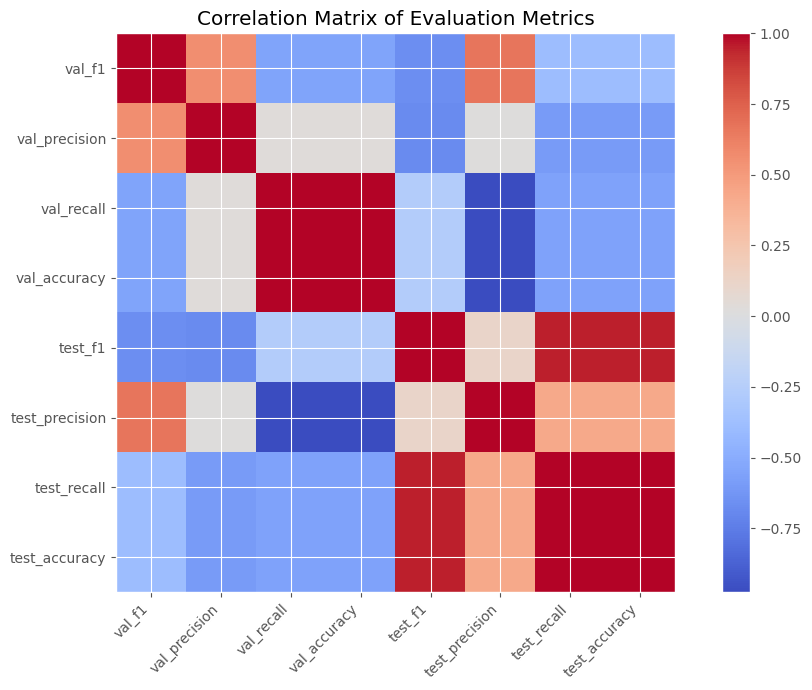

In [17]:
metric_cols = [c for c in df.columns if c not in ["model"]]
corr = df[metric_cols].corr()

plt.figure(figsize=(10, 7))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(metric_cols)), metric_cols, rotation=45, ha="right")
plt.yticks(range(len(metric_cols)), metric_cols)
plt.title("Correlation Matrix of Evaluation Metrics")
plt.tight_layout()
plt.savefig("../figures/metrics_correlation_matrix.png")
plt.show()

Table Summary

In [16]:
df_sorted.style.background_gradient(cmap="Blues")

,model,val_f1,val_precision,val_recall,val_accuracy,test_f1,test_precision,test_recall,test_accuracy
3,LightGBM,0.164448,0.246900,0.330403,0.330403,0.402424,0.409972,0.420300,0.420300
1,random_forest,0.164196,0.109232,0.330502,0.330502,0.398041,0.407778,0.414350,0.414350
2,xgboost,0.164357,0.274464,0.330469,0.330469,0.389368,0.385955,0.403725,0.403725
4,catboost,0.215795,0.260124,0.301418,0.301418,0.373146,0.540778,0.441100,0.441100
0,logistic_regression,0.209246,0.343783,0.335889,0.335889,0.247113,0.400055,0.261325,0.261325
